1. Generate a dataset (size = 1000) from a normal distribution.
○ Compute mean, variance, and standard deviation manually
○ Plot histogram and verify if it resembles a normal distribution
2. Convert the dataset into a standard normal distribution (Z-score):
○ Implement Z-score calculation manually
○ Verify mean ≈ 0 and standard deviation ≈ 1
3. Given a dataset of student marks:
○ Compute mean, median, variance, and standard deviation
○ Identify outliers using Z-score (|Z| > 2 or 3)
4. Implement a basic one-sample hypothesis test:
○ Null hypothesis: μ = given value
○ Compute Z-statistic manually
○ Conclude whether to reject H₀ at α = 0.05
5. Simulate multiple samples (at least 1000 times):
○ Perform hypothesis test each time under H₀ true
○ Estimate the false positive rate
○ Compare with significance level (α)

-0.03807022177572407 1.008529427990847 1.004255658680023


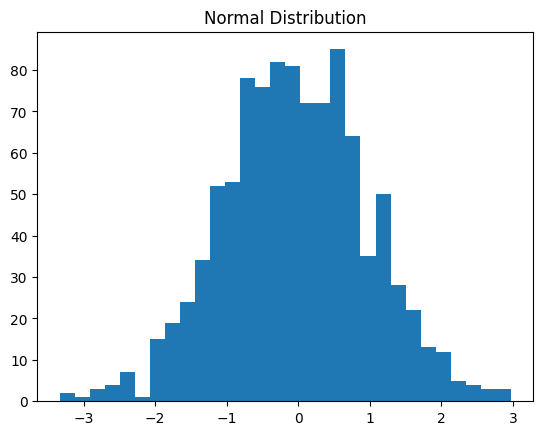

In [1]:
import random
import matplotlib.pyplot as plt

data = [random.gauss(0, 1) for _ in range(1000)]

# Mean
mean = sum(data) / len(data)

# Variance
var = sum((x - mean) ** 2 for x in data) / len(data)

# Std
std = var ** 0.5

print(mean, var, std)

plt.hist(data, bins=30)
plt.title("Normal Distribution")
plt.show()

In [2]:
z_data = []

for x in data:
    z = (x - mean) / std
    z_data.append(z)

# Verify
z_mean = sum(z_data) / len(z_data)
z_std = (sum((x - z_mean) ** 2 for x in z_data) / len(z_data)) ** 0.5

print(z_mean, z_std)

2.6867397195928787e-17 0.9999999999999998


In [3]:
marks = [50, 60, 70, 80, 90, 100, 120]

# Median
sorted_marks = sorted(marks)
n = len(marks)

if n % 2 == 1:
    median = sorted_marks[n//2]
else:
    median = (sorted_marks[n//2 - 1] + sorted_marks[n//2]) / 2

# Outliers
outliers = []
for x in marks:
    z = (x - mean) / std
    if abs(z) > 2:
        outliers.append(x)

print("Outliers:", outliers)

Outliers: [50, 60, 70, 80, 90, 100, 120]


In [4]:
import math

mu0 = 0  # hypothesized mean
z_stat = (mean - mu0) / (std / math.sqrt(len(data)))

print("Z-stat:", z_stat)

# alpha = 0.05 → critical ~ ±1.96
if abs(z_stat) > 1.96:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Z-stat: -1.1987845007242954
Fail to Reject H0


In [5]:

import random
import math

count = 0
trials = 1000

for _ in range(trials):
    sample = [random.gauss(0, 1) for _ in range(30)]
    
    mean = sum(sample)/len(sample)
    std = (sum((x-mean)**2 for x in sample)/len(sample))**0.5
    
    z = (mean - 0) / (std / math.sqrt(len(sample)))
    
    if abs(z) > 1.96:
        count += 1

print("False Positive Rate:", count / trials)

False Positive Rate: 0.059
